# Donchian 15분봉 TQQQ/SQQQ 백테스트

**목적**: `quant.backtest`를 통해 라이브와 동일한 코드 경로로 Donchian breakout
전략을 리플레이하고, 자산 곡선/지표/거래 내역을 확인한다.

**1차 목표**: stub 데이터로 파이프라인 스모크 테스트 — 전략/리스크/체결 로직이
엔드투엔드로 도는지 확인한다. 실데이터 연결은 다음 단계.

In [1]:
import sys; sys.path.insert(0, "..")

from quant.backtest import run_backtest

In [2]:
result = run_backtest(
    strategy_id="donchian",
    days=90,
    interval="15m",
    source="stub",
    settings_path="../config/settings.yaml",
)

In [3]:
import pandas as pd

pd.Series(result.metrics)

total_return_pct      -19.360
cagr_pct              -46.420
mdd_pct               -19.370
sharpe                -12.540
win_rate                7.550
profit_factor           0.009
payoff_ratio            0.111
expectancy_krw     -18266.800
n_trades               53.000
dtype: float64

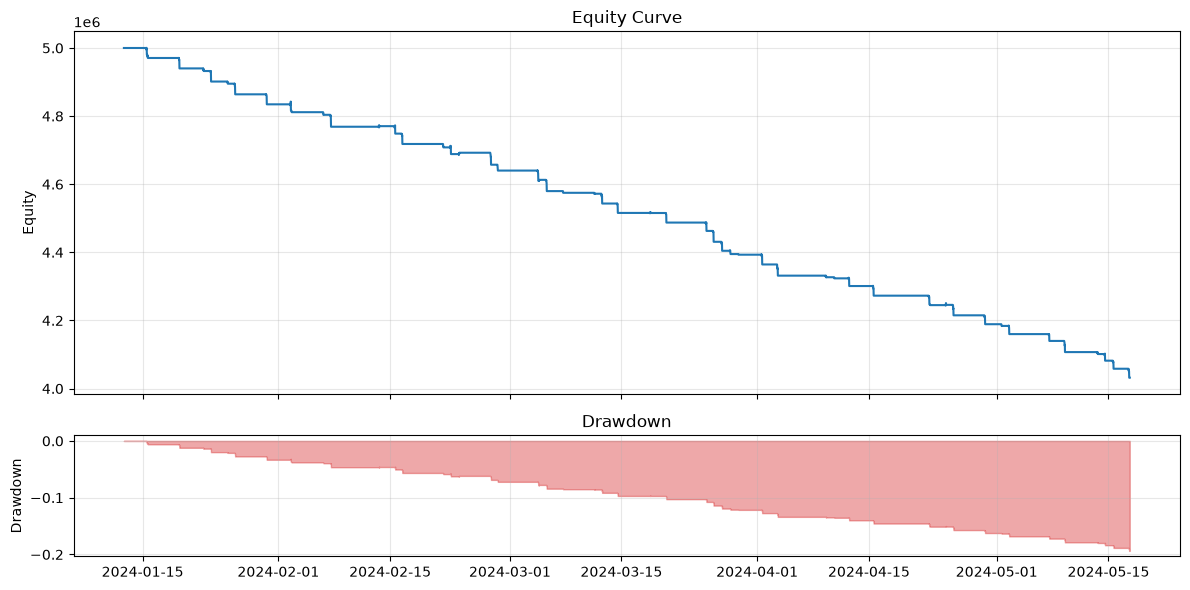

In [4]:
import matplotlib.pyplot as plt

equity = result.equity_curve
drawdown = equity / equity.cummax() - 1

fig, (ax_equity, ax_dd) = plt.subplots(
    2, 1, figsize=(12, 6), sharex=True, gridspec_kw={"height_ratios": [3, 1]}
)

ax_equity.plot(equity.index, equity.values, color="tab:blue")
ax_equity.set_title("Equity Curve")
ax_equity.set_ylabel("Equity")
ax_equity.grid(True, alpha=0.3)

ax_dd.fill_between(drawdown.index, drawdown.values, 0, color="tab:red", alpha=0.4)
ax_dd.set_title("Drawdown")
ax_dd.set_ylabel("Drawdown")
ax_dd.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [5]:
result.trades.tail(20)

,ts,symbol,side,qty,price,fee,fee_krw,realized_pnl_krw,pnl,reason
86,2024-04-25 11:59:00-04:00,TQQQ,buy,10.979047,51.575086,0.566245,849.367947,0.000000,-849.367947,15m 종가 40봉 신고가 돌파 (51.56 > 51.07) + 거래량 440653...
87,2024-04-25 13:59:00-04:00,TQQQ,sell,10.979047,49.814382,0.546914,820.371671,-28996.275671,-29816.647342,손절: entry=51.56 stop=50.79 현재=49.83
88,2024-04-29 10:59:00-04:00,SQQQ,buy,11.159219,50.375879,0.562155,843.233211,0.000000,-843.233211,15m 종가 40봉 신고가 돌파 (50.36 > 50.26) + 거래량 489353...
89,2024-04-29 12:59:00-04:00,SQQQ,sell,11.159219,48.916144,0.545866,818.798962,-24434.248857,-25253.047819,손절: entry=50.36 stop=49.61 현재=48.93
90,2024-05-01 13:59:00-04:00,TQQQ,buy,10.869227,51.399708,0.558675,838.012650,0.000000,-838.012650,15m 종가 40봉 신고가 돌파 (51.39 > 51.37) + 거래량 440122...
91,2024-05-01 15:44:00-04:00,TQQQ,sell,10.869227,51.192750,0.556426,834.638438,-3374.211586,-4208.850024,마감 전 청산: entry=51.39 stop=50.62 target=53.31 현...
92,2024-05-02 11:29:00-04:00,TQQQ,buy,10.664111,52.325224,0.558002,837.003025,0.000000,-837.003025,15m 종가 40봉 신고가 돌파 (52.31 > 51.43) + 거래량 443905...
93,2024-05-02 13:29:00-04:00,TQQQ,sell,10.664111,50.927414,0.543096,814.643417,-22359.607893,-23174.251310,손절: entry=52.31 stop=51.53 현재=50.94
94,2024-05-07 11:59:00-04:00,SQQQ,buy,10.804793,51.347558,0.554800,832.199573,0.000000,-832.199573,15m 종가 40봉 신고가 돌파 (51.33 > 51.09) + 거래량 436700...
95,2024-05-07 13:59:00-04:00,SQQQ,sell,10.804793,50.212418,0.542535,813.802138,-18397.434884,-19211.237022,손절: entry=51.33 stop=50.56 현재=50.22


## 다음 단계

- 실데이터 소스 연결 (stub → 실제 15분봉 히스토리)
- 전략 파라미터 그리드 서치 (`lookback_bars`, `volume_mult`, `risk_reward` 등)
- 전작(stock-algo-trade)의 gauntlet(다구간/다종목 검증) 이식